# 03 — Evaluación del sistema GraphRAG (metodología RAGAS)

Este notebook evalúa el pipeline usando las tres métricas **RAGAS** descritas en
clase. El enfoque **no** requiere la librería RAGAS —
todas las métricas se implementan como llamadas estructuradas al LLM.

### Las tres métricas

| Métrica | Qué mide | Cómo |
|---|---|---|
| **context_recall** | ¿El recuperador obtuvo chunks que cubren la verdad esperada? | Cada frase del ground truth se verifica: ¿puede atribuirse al contexto recuperado? |
| **faithfulness** | ¿La respuesta contiene solo cosas respaldadas por el contexto? | La respuesta se descompone en afirmaciones atómicas; cada una se verifica contra el contexto. |
| **answer_correctness** | ¿Cuánto se superpone la respuesta con el ground truth? | Las afirmaciones se clasifican en TP / FP / FN; se calcula el F1. |

### El pipeline de evaluación

```
CSV de benchmark
  (question ; cypher)
        │
        ▼
  load_dataset()       ← lee el CSV, ejecuta Cypher para obtener ground truths dinámicos
        │
        ▼
  run_benchmark()      ← llama al agente RAG para cada pregunta, registra la latencia
        │
        ▼
  evaluate_results()   ← puntúa cada fila con las tres métricas RAGAS
        │
        ▼
  print_summary()      ← tabla agregada
```

**Requisito previo:** Ejecutar `01_ingestion_demo.ipynb` para cargar los datos de Einstein en Neo4j.

## 1. Configuración

In [1]:
import sys
sys.path.append('..')
from dotenv import load_dotenv
load_dotenv("../env/.env")

import pandas as pd
from graphrag.graph.neo4j_manager import Neo4jManager
from graphrag.agents import AgenticRAG
from graphrag.evaluation import RAGEvaluator

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

/home/Pablo/Universidad/02-segundo-cuatrimestre/IAC/GraphRAG-IAC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
neo4j = Neo4jManager()
rag = AgenticRAG(neo4j)
evaluator = RAGEvaluator(rag, neo4j)
print("Sistema listo.")

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 18538.83it/s]


Sistema listo.


## 2. Inspección de métricas — pregunta a pregunta

Antes de ejecutar el benchmark completo, es instructivo ver qué hace cada métrica
internamente. Tomamos una sola pregunta y llamamos a cada métrica de forma manual.

In [3]:
question     = "Where was Einstein born?"
ground_truth = "Albert Einstein was born in Ulm, Germany."

# Preguntamos al agente
answer, context = evaluator.get_answer(question)
print(f"Respuesta       : {answer}")
print(f"Chunks recuperados: {len(context)}")

Respuesta       : Ulm [2].
Chunks recuperados: 2


In [4]:
# --- context_recall ---
# Objetivo: ¿puede atribuirse cada frase del ground truth al contexto recuperado?
# Puntuación = (frases atribuidas) / (total de frases)  →  rango [0, 1]
recall_result = evaluator.evaluate_context_recall(question, ground_truth, context, verbose=True)

print("context_recall")
print(f"  puntuación : {recall_result.get('recall', 0):.3f}")
print(f"  frases     : {recall_result.get('sentences', [])}")
print(f"  atribuidas : {recall_result.get('attributions', [])}")
print(f"  razonamiento: {recall_result.get('reasoning', '')}")


── context_recall ──────────────────────────────────
  Question    : Where was Einstein born?
  Ground truth: Albert Einstein was born in Ulm, Germany.
  Context chunks retrieved: 2

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (1):
    [✓ attributed] Albert Einstein was born in Ulm, Germany.

  Reasoning : The context contains two entries for Albert Einstein with locations 'Germany' and 'Ulm'. The ground truth states that Einstein was born in Ulm, Germany. The context explicitly mentions 'Ulm' as the location for Albert Einstein, which matches the ground truth. The ground truth is supported by the context.
  Score     : 1.000
────────────────────────────────────────────────────
context_recall
  puntuación : 1.000
  frases     : ['Albert Einstein was born in Ulm, Germany.']
  atribuidas : [1]
  razonamiento: The context contains two entries for Albert Einstein with locations 'Germany' and 'Ulm'. The ground truth states that 

In [5]:
# --- faithfulness ---
# Paso 1: descomponer la respuesta en afirmaciones atómicas sin pronombres.
# Paso 2: verificar si cada afirmación puede inferirse del contexto.
# Puntuación = (afirmaciones respaldadas) / (total)  →  rango [0, 1]
faith_result = evaluator.evaluate_faithfulness(question, answer, context, verbose=True)

print("faithfulness")
print(f"  puntuación  : {faith_result.get('faithfulness', 0):.3f}")
print(f"  afirmaciones: {faith_result.get('statements', [])}")
print(f"  veredictos  : {faith_result.get('verdicts', [])}")


── faithfulness ────────────────────────────────────
  Question: Where was Einstein born?
  Answer  : Ulm [2].

  [Step 1] Decomposing the answer into statements...
  Statements extracted (1):
    1. Einstein was born in Ulm.

  [Step 2] Context detected.
           Using retrieval-grounded mode...

  Verdicts:
    [✗ unsupported] Einstein was born in Ulm.
              → The context provides two entries for Einstein's location: 'Germany' and 'Ulm'. Since Ulm is a city in Germany, the context indicates that Einstein was born in Ulm, which is a specific location within Germany. However, the context does not explicitly state that Einstein was born in Ul: it lists 'Ulm' as a location for Einstein. The context is ambiguous because it lists two different locations. The correct answer is that Einstein was born in Ulm, Germany, but the context does not explicitly state this. The context lists 'Ulm' as a location for Einstein, but it does not specify that this is his birthplace. The context i

In [6]:
# --- answer_correctness ---
# Se descomponen tanto la respuesta como el ground truth en afirmaciones.
# Cada afirmación se clasifica en TP / FP / FN.
# Puntuación = F1(precisión, recall) calculado a partir de los conteos TP / FP / FN.
corr_result = evaluator.evaluate_answer_correctness(question, answer, ground_truth, verbose=True)

print("answer_correctness")
print(f"  F1        : {corr_result.get('answer_correctness', 0):.3f}")
print(f"  precisión : {corr_result.get('precision', 0):.3f}")
print(f"  recall    : {corr_result.get('recall', 0):.3f}")
print(f"  TP={corr_result.get('tp',0)}  FP={corr_result.get('fp',0)}  FN={corr_result.get('fn',0)}")


── answer_correctness ──────────────────────────────
  Question    : Where was Einstein born?
  Answer      : Ulm [2].
  Ground truth: Albert Einstein was born in Ulm, Germany.

  [Step 1] Decomposing the answer into statements...
  Answer statements (1):
    1. Einstein was born in Ulm

  [Step 2] Decomposing the ground truth into statements...
  Ground truth statements (1):
    1. Albert Einstein was born in Ulm, Germany.

  [Step 3] Classifying each statement as TP / FP / FN...
  Classifications:
    [TP] Einstein was born in Ulm — The statement 'Einstein was born in Ulm' is a clear paraphrase of the ground truth 'Albert Einstein was born in Ulm, Germany.' Both refer to the same fact about Einstein's birthplace without adding new information or contradicting the ground truth. The name 'Albert Einstein' is implied by context, and 'Germany' is a minor detail that doesn't change the core fact.

  TP=1  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
──────────────────────────────

## 3. Pipeline de benchmark completo

### Formato del dataset de benchmark

El benchmark es un CSV delimitado por punto y coma con dos columnas:
- `question` — la pregunta en lenguaje natural
- `cypher` — una consulta Cypher que se **ejecuta en tiempo de ejecución** para obtener el ground truth

Este diseño garantiza que los ground truths estén siempre sincronizados con el estado
real del grafo: no hay cadenas de texto codificadas que queden desactualizadas al cambiar los datos.

### Categorías de preguntas

| Categoría | Ejemplos | Propósito |
|---|---|---|
| **Saludos** | "Hello", "What can you do?" | Evaluar respuesta conversacional |
| **Fuera de ámbito** | "Weather?", "World Cup?" | Evaluar rechazo correcto |
| **Datos ausentes** | "Einstein's middle name?" | Evaluar honestidad del sistema |
| **Hechos simples** | "Where was Einstein born?" | Evaluar recuperación directa |
| **Consultas relacionales** | "Which institutions did Einstein work at?" | Evaluar traversal de grafo |
| **Consultas complejas** | "Where did Einstein live after Germany?" | Evaluar razonamiento multi-salto |
| **Agregaciones** | "How many Person nodes?" | Evaluar text2cypher |

El dataset inline cubre 20 preguntas; el CSV en `../data/benchmark_data.csv` cubre 38 preguntas.

> **⚠️ Requisito previo — datos del grafo**
>
> Las consultas Cypher de este benchmark usan el esquema de dominio nuevo
> (`Person`, `Location`, `ScientificTheory`, `Institution`, `Award`, `ScientificField`).
> Si el grafo todavía contiene nodos del esquema genérico antiguo (`Entity {type}`),
> las consultas devolverán resultados vacíos.
>
> Para reiniciar desde cero, ejecuta las dos celdas siguientes y luego vuelve a correr
> `01_ingestion_demo.ipynb` antes de continuar.

```python
# Vaciar la base de datos (¡irreversible!)
# neo4j.execute_query('MATCH (n) DETACH DELETE n')
# print('Base de datos vaciada — ejecuta 01_ingestion_demo.ipynb antes de continuar.')
```

In [3]:
DATASET_PATH = "../data/benchmark_data.csv"

dataset = pd.read_csv(DATASET_PATH, delimiter=";")
print(f"Dataset de benchmark: {len(dataset)} preguntas")
dataset[['question']]

Dataset de benchmark: 6 preguntas


,question
0,Hello!
1,What can you do?
2,What is the weather like today?
3,Good morning
4,What kind of questions can I ask you?
5,Can you give me a recipe for paella?


### 3.1 `run_benchmark()` — ejecutar ground truths Cypher y llamar al agente

Para cada fila:
1. Ejecuta la consulta Cypher → string con el ground truth
2. Llama a `rag.answer(question)` → respuesta del agente + contextos recuperados
3. Registra la latencia en segundos

In [4]:
results_df = evaluator.run_benchmark(dataset, verbose=True)

print(f"\nBenchmark completo — {len(results_df)} filas")
results_df[['question', 'ground_truth', 'answer', 'latency']]

Processing rows:   0%|          | 0/6 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [1/6] Hello!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'Hello! I am a knowledge assistant specialized in the animal kingdom. You can ask me about their taxonomy, physical or behavioral traits, diet, habitats, and conservation status.' AS ground_truth
  Ground truth: Hello! I am a knowledge assistant specialized in the animal kingdom. You can ask me about their taxonomy, physical or behavioral traits, diet, habitats, and conservation status.

  [Step 2] Calling the RAG agent...


Processing rows:  17%|█▋        | 1/6 [00:08<00:43,  8.68s/it]

  Answer  : Hello! I am a knowledge assistant specialized in the animal kingdom. You can ask me about their taxonomy, physical or behavioral traits, diet, habitats, and conservation status.
  Context chunks: 0
  Latency : 8.67s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [2/6] What can you do?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'I can answer detailed questions about specific animals. You can ask me to explore their taxonomic classification (family, genus, species), their physical characteristics, what they eat, where they live, or their conservation status.' AS ground_truth
  Ground truth: I can answer detailed questions about specific animals. You can ask me to explore their taxonomic classification (family, genus, species), their physical characteristics, what they eat, where they live, or their conservation status.

  [Step 2] Calling the RAG agent...


Processing rows:  33%|███▎      | 2/6 [00:24<00:51, 13.00s/it]

...

Processing rows:  83%|████████▎ | 5/6 [01:20<00:20, 20.57s/it]

  Answer  : Hello! I am a knowledge assistant specialized in the animal kingdom. You can ask me about their taxonomy, physical or behavioral traits, diet, habitats, and conservation status.
  Context chunks: 0
  Latency : 42.00s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [6/6] Can you give me a recipe for paella?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN 'Sorry, this question is outside my scope. I am designed to answer questions exclusively about zoology and animal biology. If you have a question about the animal world, I am ready to help!' AS ground_truth
  Ground truth: Sorry, this question is outside my scope. I am designed to answer questions exclusively about zoology and animal biology. If you have a question about the animal world, I am ready to help!

  [Step 2] Calling the RAG agent...


Processing rows: 100%|██████████| 6/6 [01:35<00:00, 15.99s/it]

  Answer  : Sorry, this question is outside my scope. I am designed to answer questions exclusively about zoology and animal biology. If you have a question about the animal world, I am ready to help!
  Context chunks: 0
  Latency : 15.41s

Benchmark completo — 6 filas


,question,ground_truth,answer,latency
0,Hello!,Hello! I am a knowledge assistant specialized in the ani...,Hello! I am a knowledge assistant specialized in the ani...,8.668
1,What can you do?,I can answer detailed questions about specific animals. ...,I can answer detailed questions about specific animals. ...,16.007
2,What is the weather like today?,"Sorry, this question is outside my scope. I am designed ...","Sorry, this question is outside my scope. I am designed ...",10.397
3,Good morning,Hello! I am a knowledge assistant specialized in the ani...,NaN,3.316
4,What kind of questions can I ask you?,I can answer detailed questions about specific animals. ...,Hello! I am a knowledge assistant specialized in the ani...,41.998
5,Can you give me a recipe for paella?,"Sorry, this question is outside my scope. I am designed ...","Sorry, this question is outside my scope. I am designed ...",15.409


### 3.2 `evaluate_results()` — puntuar cada fila con las tres métricas RAGAS

Este paso es el más intensivo en LLM: cada fila hace ~5 llamadas al LLM
(context_recall × 1, faithfulness × 2, answer_correctness × 3).
Esperar unos 10–30 segundos por fila dependiendo del modelo.

In [9]:
scored_df = evaluator.evaluate_results(results_df, verbose=True)

print(f"\nPuntuación completada.")
scored_df[['question', 'context_recall', 'faithfulness', 'answer_correctness', 'latency']]

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: Hello
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : Hello
  Ground truth: Hello! I am a knowledge assistant specialising in physicists and their scientific contributions. You can ask me about people like Albert Einstein, theories they developed, awards they received, institutions they worked at, and locations they lived in.
  Context chunks retrieved: 0

  [Step 1] No retrieved context detected.
    [✓ attributed] Hello! I am a knowledge assistant specialising in physicists and their scientific contributions. You can ask me about people like Albert Einstein, theories they developed, awards they received, institutions they worked at, and locations they lived in.

  Reasoning : No context was retrieved, and the ground truth is a conversational, scope-refusal, or KB-abstention response that requires no knowledge lookup. Recall = 1.0.
  Sco

Evaluating:   5%|▌         | 1/20 [00:21<06:39, 21.01s/it]

  Classifications:
    [TP] Hello — Exact match with ground truth statement 1
    [TP] I am a knowledge assistant — Exact match with ground truth statement 2
    [TP] I specialise in physicists — Exact match with ground truth statement 3
    [TP] I am knowledgeable about their scientific contributions — Exact match with ground truth statement 4
    [TP] You can ask me about people like Albert Einstein — Exact match with ground truth statement 5
    [TP] You can ask me about theories they developed — Exact match with ground truth statement 6
    [TP] You can ask me about awards they received — Exact match with ground truth statement 7
    [TP] You can ask me about institutions they worked at — Exact match with ground truth statement 8
    [TP] You can ask me about locations they lived in — Exact match with ground truth statement 9

  TP=9  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Evaluating:  10%|█         | 2/20 [00:51<07:54, 26.38s/it]

...

Evaluating:  95%|█████████▌| 19/20 [04:02<00:11, 11.43s/it]

  Classifications:
    [TP] The graph contains two Institution nodes. — The statement 'The graph contains two Institution nodes.' is a paraphrase of the ground truth 'The graph contains two institution nodes.' with a capitalization difference in 'Institution' vs 'institution' and a minor stylistic variation. Both statements convey the same meaning: the graph has exactly two institution nodes. Capitalization differences in nouns (e.g., 'Institution' vs 'institution') do not change the semantic meaning, and this is a clear restatement of the ground truth.

  TP=1  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: How many typed relationships exist in the graph?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : How many typed relationships exist in the graph?
  Ground truth: 11 relationsh

Evaluating: 100%|██████████| 20/20 [04:08<00:00, 12.40s/it]

  Classifications:
    [TP] This information is not in the knowledge base. — The ground truth states the graph has eleven typed relationships. The answer statement indicates that the specific information (about the graph having eleven typed relationships) is not in the knowledge base. This is a clear implication that the ground truth is not present in the knowledge base, so it's a true positive.

  TP=1  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

Puntuación completada.


,question,context_recall,faithfulness,answer_correctness,latency
0,Hello,1.000,1.000,1.000,2.508
1,What can you do?,1.000,0.000,0.933,1.889
2,What is the weather like today?,1.000,0.000,1.000,2.129
3,Which movies did Einstein appear in?,1.000,0.000,1.000,2.429
4,What is Einstein's middle name?,1.000,0.000,0.667,22.517
5,Who was Einstein's wife?,1.000,1.000,1.000,3.800
6,Where was Einstein born?,0.667,1.000,1.000,19.324
7,What is Einstein's nationality?,1.000,0.000,1.000,48.449
8,In what year was Einstein born?,1.000,1.000,1.000,6.005
9,What award did Einstein receive?,1.000,1.000,1.000,5.017


### 3.3 `print_summary()` — resultados agregados

El resumen reproduce la tabla de resumen de benchmark que hemos comentado en clase.
Un sistema bien ajustado debería superar 0.7 en las tres métricas.

In [10]:
evaluator.print_summary(scored_df)


=== Benchmark Summary ===
answer_correctness       : 0.8383
context_recall           : 0.6905
faithfulness             : 0.6500
avg_latency_s            : 22.54


## 4. Análisis de resultados

### 4.1 Distribución por métrica

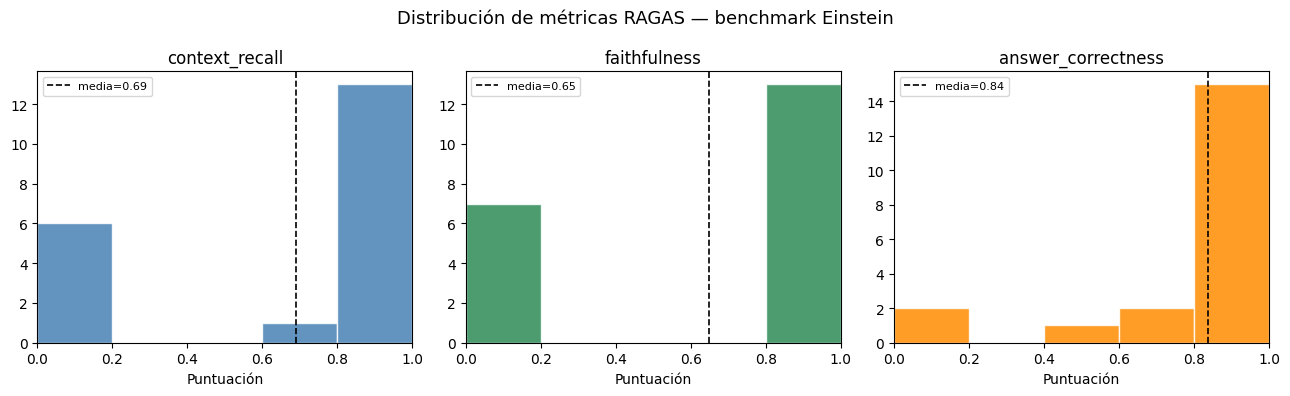

In [11]:
import matplotlib.pyplot as plt

metrics = ['context_recall', 'faithfulness', 'answer_correctness']
colors  = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Distribución de métricas RAGAS — benchmark Einstein', fontsize=13)

for ax, metric, color in zip(axes, metrics, colors):
    ax.hist(scored_df[metric].dropna(), bins=5, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(scored_df[metric].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'media={scored_df[metric].mean():.2f}')
    ax.set_title(metric)
    ax.set_xlabel('Puntuación')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

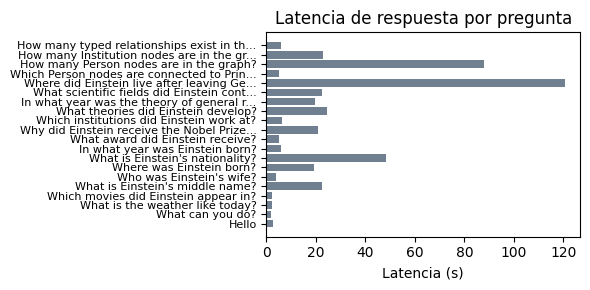

In [12]:
# Distribución de latencia
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(range(len(scored_df)), scored_df['latency'], color='slategray')
ax.set_yticks(range(len(scored_df)))
ax.set_yticklabels(
    [q[:40] + '...' if len(q) > 40 else q for q in scored_df['question']],
    fontsize=8
)
ax.set_xlabel('Latencia (s)')
ax.set_title('Latencia de respuesta por pregunta')
plt.tight_layout()
plt.show()

### 4.2 Mejor y peor caso por answer_correctness

Inspeccionar los extremos ayuda a diagnosticar *por qué* falla el sistema:
- `context_recall` bajo → el recuperador no encontró los chunks relevantes → ajustar `chunk_size` o `top_k`
- `faithfulness` bajo → el LLM alucinó → mejorar el prompt de respuesta o añadir instrucciones de anclaje
- `answer_correctness` bajo con `faithfulness` alto → el contexto recuperado era incompleto

In [13]:
def show_case(label, row):
    print(f"{'='*70}")
    print(label)
    print(f"{'='*70}")
    print(f"Question        : {row['question']}")
    print(f"Ground truth    : {str(row['ground_truth'])[:200]}")
    print(f"Answer          : {str(row['answer'])[:200]}")
    print(f"answer_correctness : {row['answer_correctness']:.3f}")
    print(f"context_recall     : {row['context_recall']:.3f}")
    print(f"faithfulness       : {row['faithfulness']:.3f}")
    print()

best_idx  = scored_df['answer_correctness'].idxmax()
worst_idx = scored_df['answer_correctness'].idxmin()

show_case("MEJOR CASO",  scored_df.loc[best_idx])
show_case("PEOR CASO", scored_df.loc[worst_idx])

MEJOR CASO
Question        : Hello
Ground truth    : Hello! I am a knowledge assistant specialising in physicists and their scientific contributions. You can ask me about people like Albert Einstein, theories they developed, awards they received, instit
Answer          : Hello! I am a knowledge assistant specialising in physicists and their scientific contributions. You can ask me about people like Albert Einstein, theories they developed, awards they received, instit
answer_correctness : 1.000
context_recall     : 1.000
faithfulness       : 1.000

PEOR CASO
Question        : Which institutions did Einstein work at?
Ground truth    : Swiss Patent Office; Institute for Advanced Study
Answer          : This information is not in the knowledge base.
answer_correctness : 0.000
context_recall     : 0.000
faithfulness       : 1.000



### 4.3 Correlación entre métricas

¿Son las tres métricas independientes o tienden a moverse juntas?
Una correlación fuerte entre `context_recall` y `answer_correctness` confirmaría
que la calidad de la recuperación es el principal cuello de botella.

In [14]:
corr = scored_df[metrics].corr()
print("Correlación de Pearson entre métricas:")
print(corr.round(3))

Correlación de Pearson entre métricas:
                    context_recall  faithfulness  answer_correctness
context_recall               1.000        -0.039               0.661
faithfulness                -0.039         1.000               0.034
answer_correctness           0.661         0.034               1.000


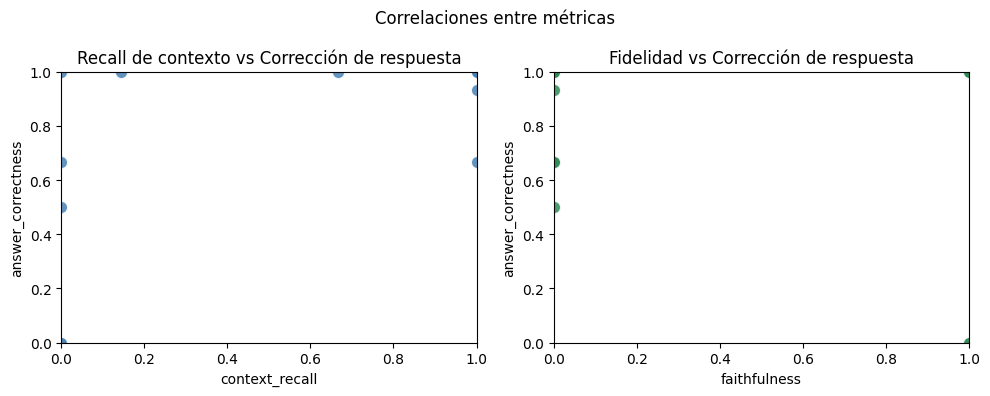

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(scored_df['context_recall'], scored_df['answer_correctness'],
                color='steelblue', edgecolors='white', s=80, alpha=0.85)
axes[0].set_xlabel('context_recall')
axes[0].set_ylabel('answer_correctness')
axes[0].set_title('Recall de contexto vs Corrección de respuesta')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].scatter(scored_df['faithfulness'], scored_df['answer_correctness'],
                color='seagreen', edgecolors='white', s=80, alpha=0.85)
axes[1].set_xlabel('faithfulness')
axes[1].set_ylabel('answer_correctness')
axes[1].set_title('Fidelidad vs Corrección de respuesta')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle('Correlaciones entre métricas', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Uso de un fichero CSV de benchmark

Para una evaluación real se mantiene un CSV versionado junto al código.
El formato es idéntico — `load_dataset()` simplemente lo lee desde disco.
Las consultas Cypher se adaptan automáticamente a los datos actuales del grafo.

In [16]:
# Cargar el CSV de benchmark del proyecto (preguntas genéricas sobre la estructura del grafo)
generic_dataset = evaluator.load_dataset('../data/benchmark_data.csv')
print(f"Benchmark CSV: {len(generic_dataset)} preguntas")
generic_dataset[['question']]

Benchmark CSV: 38 preguntas


,question
0,Hello
1,What can you do?
2,"Thank you, goodbye!"
3,What is the weather like today?
4,Who won the last football World Cup?
5,What is the capital of France?
6,What is Einstein's middle name?
7,Who was Einstein's wife?
8,"What is the population of Ulm, Germany?"
9,Which movies did Einstein appear in?


In [17]:
# Ejecutar el pipeline completo sobre el benchmark CSV
# (descomenta si quieres correrlo — tarda varios minutos)

# generic_results = evaluator.run_benchmark(generic_dataset)
# generic_scored  = evaluator.evaluate_results(generic_results)
# evaluator.print_summary(generic_scored)

## 6. Guardar resultados

In [18]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"../data/evaluation_results_{timestamp}.csv"
scored_df.to_csv(out_path, index=False)
print(f"Resultados guardados en {out_path}")

Resultados guardados en ../data/evaluation_results_20260420_141918.csv


In [19]:
neo4j.close()